# 03 - Error analysis

**Goal:** find out *where and why* the model gets Hinglish wrong. This is the part that makes the project more than a table of numbers.

In [1]:
%pip install -q ftfy tweet-preprocessor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/23f2004336/hinglish-sentiment.git"

def has_src(base):
    return os.path.exists(os.path.join(base, "src", "data.py"))

if has_src(".."):
    sys.path.insert(0, "..")
    RESULTS_DIR = "../results"
elif has_src("."):
    sys.path.insert(0, ".")
    RESULTS_DIR = "results"
else:
    if not os.path.exists("hinglish-sentiment"):
        subprocess.run(["git", "clone", REPO_URL], check=True)   # needs Internet ON in Kaggle
    sys.path.insert(0, os.path.abspath("hinglish-sentiment"))
    RESULTS_DIR = "."

Cloning into 'hinglish-sentiment'...


In [3]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
from transformers import pipeline
from src.data import load_data

HF_USER = "Shrishti03"      
REPO_ID = f"{HF_USER}/hinglish-sentiment-muril"
NAMES = {0: "negative", 1: "neutral", 2: "positive"}

dfs = load_data()
test = dfs["test"].copy()

README.md:   0%|          | 0.00/533 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 22.2MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.92MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.98MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/96761 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8538 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8538 [00:00<?, ? examples/s]

## Predict on the test set with the saved model

In [4]:
clf = pipeline(
    "text-classification", model=REPO_ID, tokenizer=REPO_ID,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=128, batch_size=64,
)
outs = clf(test.text.tolist())
test["pred"] = [int(o["label"].split("_")[-1]) for o in outs]

y, p, m = test.label.values, test.pred.values, test.hinglish.values
print("Overall :", round(f1_score(y, p, average="macro"), 3))
print("Hinglish:", round(f1_score(y[m], p[m], average="macro"), 3))
print("English :", round(f1_score(y[~m], p[~m], average="macro"), 3))

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  950MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

Overall : 0.847
Hinglish: 0.624
English : 0.856


## Confusion matrix (Hinglish only)

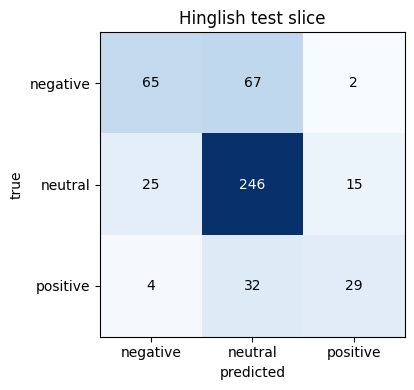

In [5]:
h = test[test.hinglish].copy()
cm = confusion_matrix(h.label, h.pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
labels = [NAMES[i] for i in range(3)]
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Hinglish test slice")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [6]:
def show(true, predicted, n=8):
    rows = h[(h.label == true) & (h.pred == predicted)]
    print(f"\n=== true {NAMES[true]} -> predicted {NAMES[predicted]}  ({len(rows)} rows) ===")
    for t in rows.text.head(n):
        print("-", t[:160])

show(0, 1)   
show(2, 1)   
show(1, 0)   
show(1, 2)   


=== true negative -> predicted neutral  (67 rows) ===
- jab sale lagti h tab rakhte hei .. jab khud ka kaam khatam toh human explotation karte hein ..
- rt apni maa ke baare main aisa nahi bolte tere abba the linguist ne sikhayea nahi tuj …
- kaisa pagal journalist hai ye itna bhi nahi pata ke ye ek fake footage hai 🤣
- _ jo samajh aat nahi usmey taang mat adao kahin aur time …
- rt kaun itna chutiya schedule banaya hai koi team 1 match nahi kheli hai or yaha kuch tean 2-2 khel li hai waah bc 😡
- rohit babu ptrakarita ka to p bhi aap nahi jaante jo vyakti satta k talve chaatata ho vo patrakaar h …
- ha sahi suna h 1988 ke email jaisa . pehle khud ka system toh update kr lo . bahut saare virus h sinha babu .
- " hasi toh phasi " is so fake it ' s actually agar wo hasi toh phasa tu harami .

=== true positive -> predicted neutral  (32 rows) ===
- rt wo jo gaane hai jo ki lip sync nahi unke koi mayne hai nahi jo bhi gaane jo hit hue hai wo all lip sync ke hue hai …
- apne desh ke sainik 

## Does text length matter?

In [7]:
h["n_words"] = h.text.str.split().str.len()
h["bucket"] = pd.cut(h.n_words, [0, 5, 10, 20, 1000], labels=["<=5", "6-10", "11-20", "20+"])
h["correct"] = h.label == h.pred
h.groupby("bucket", observed=True).correct.agg(["mean", "size"]).round(2)

,mean,size
bucket,,
<=5,1.00,1
6-10,0.63,19
11-20,0.70,222
20+,0.71,243


## Findings 

* The model plays it safe on Hinglish. It predicts neutral for 71% of rows (true share: 59%), and 68% of its errors are a negative or positive tweet labeled neutral.
* It rarely confuses opposite sentiments: only 6 of 145 errors are negative vs positive.
* Recall on Hinglish: negative 0.49, neutral 0.86, positive 0.45. Positive and negative are hurt by slang, abuse and sarcasm in romanized Hindi, which is rare in training (about 5% of rows).
* Accuracy doesn’t change much with tweet length (about 0.70 for 11+ words).
* Labels look noisy in places: congratulations marked neutral, and abusive or critical tweets marked neutral. Some errors are likely label errors.
* Many tweets are truncated in the source data, so the sentiment may be cut off.
* Next steps: oversample or collect more Hinglish data, add class weights, and tune the neutral decision threshold on the validation set.